In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from itertools import combinations
from tabulate import tabulate
from rapidfuzz import fuzz
from Levenshtein import distance as levenshtein_distance
import fuzzy
import skfuzzy as fuzz_logic

### 1. Завантаження датасету

In [123]:
data = pd.read_csv("./room_type.csv")

data.head()

,Expedia,Booking.com
0,"Deluxe Room, 1 King Bed",Deluxe King Room
1,"Standard Room, 1 King Bed, Accessible",Standard King Roll-in Shower Accessible
2,"Grand Corner King Room, 1 King Bed",Grand Corner King Room
3,"Suite, 1 King Bed (Parlor)",King Parlor Suite
4,"High-Floor Premium Room, 1 King Bed",High-Floor Premium King Room


In [124]:
data.columns

Index(['Expedia', 'Booking.com'], dtype='object')

### 2. Реалізація метрик схожості

Для кожної пари рядків рахуємо три метрики:
- **Jaro-Winkler** — схожість символів з бонусом за спільний початок
- **Soundex** — фонетична схожість (чи однаково звучать)
- **Damerau-Levenshtein** — кількість операцій редагування

In [125]:
def jaro_winkler_score(str1, str2):
    score = fuzz.token_sort_ratio(str(str1), str(str2)) / 100
    return round(score, 3)

soundex_encoder = fuzzy.Soundex(4)

def soundex_score(str1, str2):
    try:
        s1 = soundex_encoder(str(str1).split()[0])  
        s2 = soundex_encoder(str(str2).split()[0])
        return 1.0 if s1 == s2 else 0.0
    except:
        return 0.0


def dl_score(str1, str2):
    """
    Повертає нормалізовану схожість від 0.0 до 1.0
    на основі відстані Damerau-Levenshtein
    (чим менше операцій — тим більше значення)
    """
    dist = levenshtein_distance(str(str1).lower(), str(str2).lower())
    return round(1 / (1 + dist), 3), dist

In [126]:
def get_dl_info(row):
    dl, raw_dist = dl_score(row["Expedia"], row["Booking.com"])
    return pd.Series([dl, raw_dist])

data["jw"] = data.apply(lambda x: jaro_winkler_score(x["Expedia"], x["Booking.com"]), axis=1)
data["soundex"] = data.apply(lambda x: soundex_score(x["Expedia"], x["Booking.com"]), axis=1)

data[["dl", "dl_n_oper"]] = data.apply(get_dl_info, axis=1)

In [127]:
data['len_expedia']  = data['Expedia'].str.len()
data['len_booking']  = data['Booking.com'].str.len()
data['len_avg']      = ((data['len_expedia'] + data['len_booking']) / 2).round(1)
data['len_diff']     = (data['len_expedia'] - data['len_booking']).abs()

In [128]:
data.head()

,Expedia,Booking.com,jw,soundex,dl,dl_n_oper,len_expedia,len_booking,len_avg,len_diff
0,"Deluxe Room, 1 King Bed",Deluxe King Room,0.821,1.0,0.077,12.0,23,16,19.5,7
1,"Standard Room, 1 King Bed, Accessible",Standard King Roll-in Shower Accessible,0.737,1.0,0.056,17.0,37,39,38.0,2
2,"Grand Corner King Room, 1 King Bed",Grand Corner King Room,0.786,1.0,0.077,12.0,34,22,28.0,12
3,"Suite, 1 King Bed (Parlor)",King Parlor Suite,0.558,0.0,0.048,20.0,26,17,21.5,9
4,"High-Floor Premium Room, 1 King Bed",High-Floor Premium King Room,0.889,1.0,0.077,12.0,35,28,31.5,7


In [129]:
metrics = {
    'Jaro-Winkler (jw)': data['jw'],
    'Soundex':           data['soundex'],
    'D-L (dl)':          data['dl'],
    'Length (len_avg)':  data['len_avg'],
}

for name, series in metrics.items():
    print(f"\n  {name}:")
    print(f"    min    = {series.min():.3f}")
    print(f"    25%    = {series.quantile(0.25):.3f}")
    print(f"    median = {series.median():.3f}")
    print(f"    75%    = {series.quantile(0.75):.3f}")
    print(f"    max    = {series.max():.3f}")
    print(f"    mean   = {series.mean():.3f}")
    print(f"    std    = {series.std():.3f}")


  Jaro-Winkler (jw):
    min    = 0.346
    25%    = 0.565
    median = 0.667
    75%    = 0.784
    max    = 1.000
    mean   = 0.674
    std    = 0.144

  Soundex:
    min    = 0.000
    25%    = 0.000
    median = 1.000
    75%    = 1.000
    max    = 1.000
    mean   = 0.515
    std    = 0.502

  D-L (dl):
    min    = 0.019
    25%    = 0.036
    median = 0.048
    75%    = 0.077
    max    = 1.000
    mean   = 0.074
    std    = 0.115

  Length (len_avg):
    min    = 12.000
    25%    = 23.250
    median = 28.000
    75%    = 36.500
    max    = 63.500
    mean   = 30.335
    std    = 10.672


### 3. Нечіткі множини та функції належності

In [130]:
x_sim = np.arange(0, 1.01, 0.01)
sim_low    = fuzz_logic.trimf(x_sim, [0.0,  0.0,   0.60])
sim_medium = fuzz_logic.trimf(x_sim, [0.50, 0.667, 0.82])
sim_high   = fuzz_logic.trimf(x_sim, [0.70, 1.0,   1.0])

x_phon = np.arange(0, 1.01, 0.01)
phon_none    = fuzz_logic.trimf(x_phon, [0.0, 0.0, 0.4])
phon_partial = fuzz_logic.trimf(x_phon, [0.3, 0.5, 0.7])
phon_full    = fuzz_logic.trimf(x_phon, [0.6, 1.0, 1.0])

x_dl = np.arange(0, 1.01, 0.01)
dl_low    = fuzz_logic.trimf(x_dl, [0.0,   0.019, 0.048])
dl_medium = fuzz_logic.trimf(x_dl, [0.030, 0.060, 0.10])
dl_high   = fuzz_logic.trimf(x_dl, [0.07,  1.0,   1.0])

x_len = np.arange(12, 65, 0.5)
len_short  = fuzz_logic.trimf(x_len, [12,    12,    28.0])  
len_medium = fuzz_logic.trimf(x_len, [20.0,  28.0,  40.0])  
len_long   = fuzz_logic.trimf(x_len, [32.0,  63.5,  63.5])  

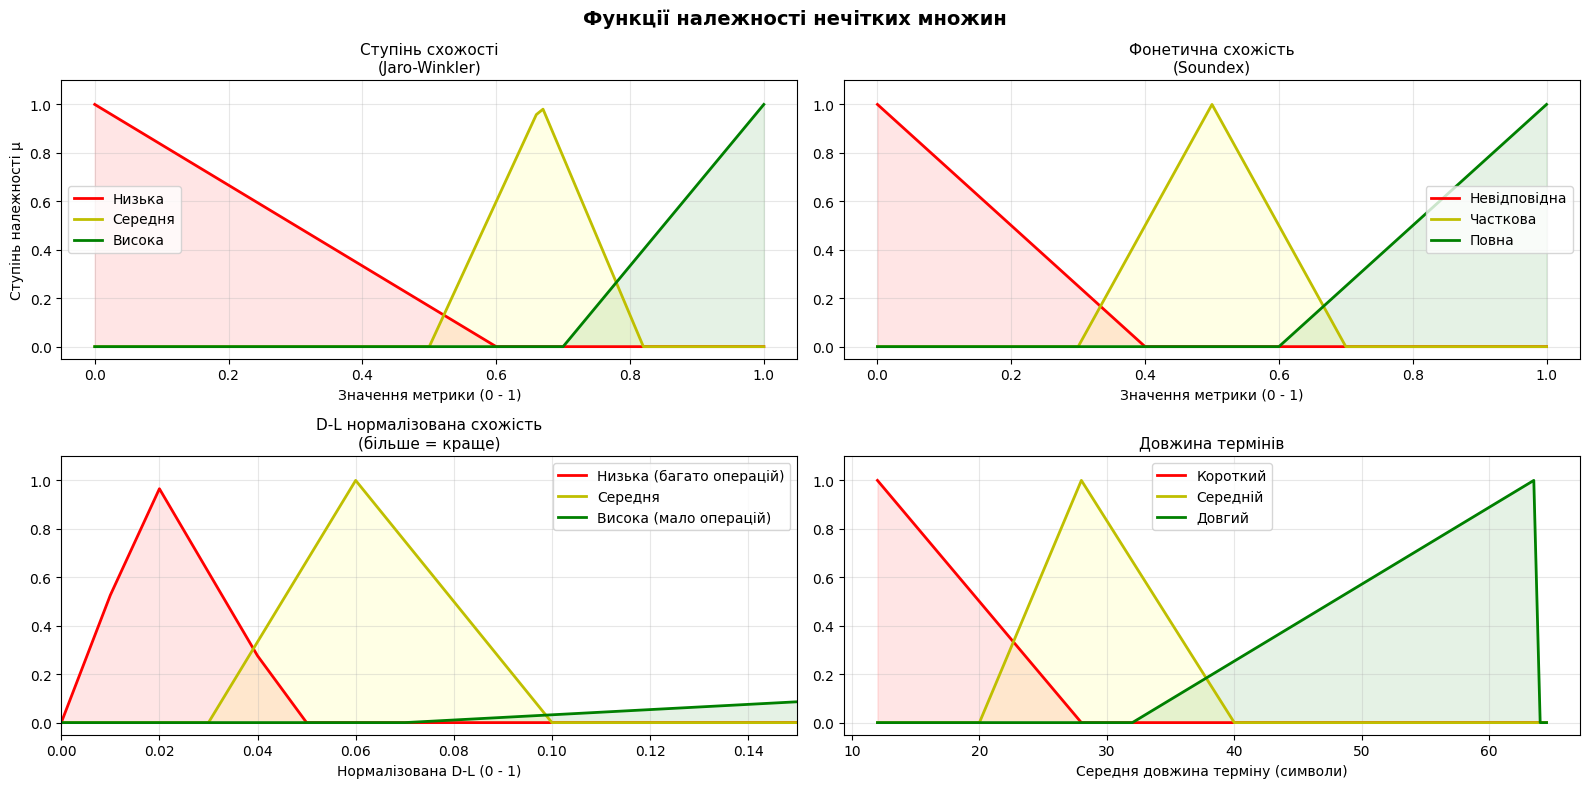

In [131]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Функції належності нечітких множин', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.plot(x_sim, sim_low,    'r-', linewidth=2, label='Низька')
ax.plot(x_sim, sim_medium, 'y-', linewidth=2, label='Середня')
ax.plot(x_sim, sim_high,   'g-', linewidth=2, label='Висока')
ax.fill_between(x_sim, sim_low,    alpha=0.1, color='red')
ax.fill_between(x_sim, sim_medium, alpha=0.1, color='yellow')
ax.fill_between(x_sim, sim_high,   alpha=0.1, color='green')
ax.set_title('Ступінь схожості\n(Jaro-Winkler)', fontsize=11)
ax.set_xlabel('Значення метрики (0 - 1)')
ax.set_ylabel('Ступінь належності μ')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.1)

ax = axes[0, 1]
ax.plot(x_phon, phon_none,    'r-', linewidth=2, label='Невідповідна')
ax.plot(x_phon, phon_partial, 'y-', linewidth=2, label='Часткова')
ax.plot(x_phon, phon_full,    'g-', linewidth=2, label='Повна')
ax.fill_between(x_phon, phon_none,    alpha=0.1, color='red')
ax.fill_between(x_phon, phon_partial, alpha=0.1, color='yellow')
ax.fill_between(x_phon, phon_full,    alpha=0.1, color='green')
ax.set_title('Фонетична схожість\n(Soundex)', fontsize=11)
ax.set_xlabel('Значення метрики (0 - 1)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.1)

ax = axes[1, 0]
ax.plot(x_dl, dl_low,    'r-', linewidth=2, label='Низька (багато операцій)')
ax.plot(x_dl, dl_medium, 'y-', linewidth=2, label='Середня')
ax.plot(x_dl, dl_high,   'g-', linewidth=2, label='Висока (мало операцій)')
ax.fill_between(x_dl, dl_low,    alpha=0.1, color='red')
ax.fill_between(x_dl, dl_medium, alpha=0.1, color='yellow')
ax.fill_between(x_dl, dl_high,   alpha=0.1, color='green')
ax.set_title('D-L нормалізована схожість\n(більше = краще)', fontsize=11)
ax.set_xlabel('Нормалізована D-L (0 - 1)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.1)
ax.set_xlim(0, 0.15)

ax = axes[1, 1]
ax.plot(x_len, len_short,  'r-', linewidth=2, label='Короткий')
ax.plot(x_len, len_medium, 'y-', linewidth=2, label='Середній')
ax.plot(x_len, len_long,   'g-', linewidth=2, label='Довгий')
ax.fill_between(x_len, len_short,  alpha=0.1, color='red')
ax.fill_between(x_len, len_medium, alpha=0.1, color='yellow')
ax.fill_between(x_len, len_long,   alpha=0.1, color='green')
ax.set_title('Довжина термінів', fontsize=11)
ax.set_xlabel('Середня довжина терміну (символи)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

### 4. Функція фазифікації

In [132]:
def fuzzify_similarity(value):
    return {
        'low':    fuzz_logic.interp_membership(x_sim, sim_low,    value),
        'medium': fuzz_logic.interp_membership(x_sim, sim_medium, value),
        'high':   fuzz_logic.interp_membership(x_sim, sim_high,   value)
    }

def fuzzify_phonetic(value):
    return {
        'none':    fuzz_logic.interp_membership(x_phon, phon_none,    value),
        'partial': fuzz_logic.interp_membership(x_phon, phon_partial, value),
        'full':    fuzz_logic.interp_membership(x_phon, phon_full,    value)
    }

def fuzzify_dl(value):              
    return {
        'low':    fuzz_logic.interp_membership(x_dl, dl_low,    value),  
        'medium': fuzz_logic.interp_membership(x_dl, dl_medium, value),
        'high':   fuzz_logic.interp_membership(x_dl, dl_high,   value)
    }


def fuzzify_length(value):
    return {
        'short':  fuzz_logic.interp_membership(x_len, len_short,  value),
        'medium': fuzz_logic.interp_membership(x_len, len_medium, value),
        'long':   fuzz_logic.interp_membership(x_len, len_long,   value)
    }

In [133]:
data["sim_low"]    = data["jw"].apply(lambda x: fuzzify_similarity(x)['low'])
data["sim_medium"] = data["jw"].apply(lambda x: fuzzify_similarity(x)['medium'])
data["sim_high"]   = data["jw"].apply(lambda x: fuzzify_similarity(x)['high'])

data["phon_none"]    = data["soundex"].apply(lambda x: fuzzify_phonetic(x)['none'])
data["phon_partial"] = data["soundex"].apply(lambda x: fuzzify_phonetic(x)['partial'])
data["phon_full"]    = data["soundex"].apply(lambda x: fuzzify_phonetic(x)['full'])

data["dl_low"]    = data["dl"].apply(lambda x: fuzzify_dl(x)['low'])
data["dl_medium"] = data["dl"].apply(lambda x: fuzzify_dl(x)['medium'])
data["dl_high"]   = data["dl"].apply(lambda x: fuzzify_dl(x)['high'])

data["len_short"]  = data["len_avg"].apply(lambda x: fuzzify_length(x)['short'])
data["len_medium"] = data["len_avg"].apply(lambda x: fuzzify_length(x)['medium'])
data["len_long"]   = data["len_avg"].apply(lambda x: fuzzify_length(x)['long'])

In [134]:
data.head()

,Expedia,Booking.com,jw,soundex,dl,dl_n_oper,len_expedia,len_booking,len_avg,len_diff,...,sim_high,phon_none,phon_partial,phon_full,dl_low,dl_medium,dl_high,len_short,len_medium,len_long
0,"Deluxe Room, 1 King Bed",Deluxe King Room,0.821,1.0,0.077,12.0,23,16,19.5,7,...,0.403333,0.0,0.0,1.0,0.000000,0.575000,0.007527,0.53125,0.000000,0.000000
1,"Standard Room, 1 King Bed, Accessible",Standard King Roll-in Shower Accessible,0.737,1.0,0.056,17.0,37,39,38.0,2,...,0.123333,0.0,0.0,1.0,0.000000,0.866667,0.000000,0.00000,0.166667,0.190476
2,"Grand Corner King Room, 1 King Bed",Grand Corner King Room,0.786,1.0,0.077,12.0,34,22,28.0,12,...,0.286667,0.0,0.0,1.0,0.000000,0.575000,0.007527,0.00000,1.000000,0.000000
3,"Suite, 1 King Bed (Parlor)",King Parlor Suite,0.558,0.0,0.048,20.0,26,17,21.5,9,...,0.000000,1.0,0.0,0.0,0.055172,0.600000,0.000000,0.40625,0.187500,0.000000
4,"High-Floor Premium Room, 1 King Bed",High-Floor Premium King Room,0.889,1.0,0.077,12.0,35,28,31.5,7,...,0.630000,0.0,0.0,1.0,0.000000,0.575000,0.007527,0.00000,0.708333,0.000000


### 5. База правил нечіткого виведення (if-then)

In [135]:
# ПРАВИЛО 1: JW висока І фонетика повна → НАЛЕЖИТЬ
rule1_activation = np.minimum(data["sim_high"], data["phon_full"])
rule1_output     = rule1_activation * 0.90

# ПРАВИЛО 2: JW середня І D-L висока І короткий термін → ймовірно НАЛЕЖИТЬ
rule2_activation = np.minimum.reduce([data["sim_medium"], data["dl_high"], data["len_short"]])  
rule2_output     = rule2_activation * 0.80

# ПРАВИЛО 3: JW низька І фонетика невідповідна → НЕ НАЛЕЖИТЬ (штраф)
rule3_activation = np.minimum(data["sim_low"], data["phon_none"])
rule3_output     = rule3_activation * 0.80

# ПРАВИЛО 4: JW висока І довжина середня/довга → ймовірно НАЛЕЖИТЬ, навіть якщо фонетика часткова
rule4_activation = np.minimum(data["sim_high"], np.maximum(data["len_medium"], data["len_long"]))
rule4_output     = rule4_activation * 0.75

# АГРЕГАЦІЯ
positive_signal = np.maximum.reduce([rule1_output, rule2_output, rule4_output])
penalty         = rule3_output

# ДЕФАЗИФІКАЦІЯ
data["result"] = np.maximum(0.0, np.minimum(1.0, positive_signal - penalty * 0.3))

In [136]:
data.head()

,Expedia,Booking.com,jw,soundex,dl,dl_n_oper,len_expedia,len_booking,len_avg,len_diff,...,phon_none,phon_partial,phon_full,dl_low,dl_medium,dl_high,len_short,len_medium,len_long,result
0,"Deluxe Room, 1 King Bed",Deluxe King Room,0.821,1.0,0.077,12.0,23,16,19.5,7,...,0.0,0.0,1.0,0.000000,0.575000,0.007527,0.53125,0.000000,0.000000,0.363
1,"Standard Room, 1 King Bed, Accessible",Standard King Roll-in Shower Accessible,0.737,1.0,0.056,17.0,37,39,38.0,2,...,0.0,0.0,1.0,0.000000,0.866667,0.000000,0.00000,0.166667,0.190476,0.111
2,"Grand Corner King Room, 1 King Bed",Grand Corner King Room,0.786,1.0,0.077,12.0,34,22,28.0,12,...,0.0,0.0,1.0,0.000000,0.575000,0.007527,0.00000,1.000000,0.000000,0.258
3,"Suite, 1 King Bed (Parlor)",King Parlor Suite,0.558,0.0,0.048,20.0,26,17,21.5,9,...,1.0,0.0,0.0,0.055172,0.600000,0.000000,0.40625,0.187500,0.000000,0.000
4,"High-Floor Premium Room, 1 King Bed",High-Floor Premium King Room,0.889,1.0,0.077,12.0,35,28,31.5,7,...,0.0,0.0,1.0,0.000000,0.575000,0.007527,0.00000,0.708333,0.000000,0.567


### 6. Результати 

In [137]:
data.sort_values(by="result", ascending=False).head(10)[["Expedia", "Booking.com", "result"]]

,Expedia,Booking.com,result
47,Deluxe Suite,Deluxe Suite,0.900
94,"Regency Club, Mountain View",Regency Club Mountain View,0.843
95,"Regency Club, Ocean View",Regency Club Ocean View,0.837
4,"High-Floor Premium Room, 1 King Bed",High-Floor Premium King Room,0.567
73,"Standard Room, Ocean View",Standard Room With Ocean View,0.567
26,"Deluxe Room, 2 Queen Beds",Deluxe Room - Two Queen Beds,0.504
25,"Deluxe Room, 1 King Bed",Deluxe Room - One King Bed,0.471
57,"Deluxe Suite, 1 Bedroom",Deluxe One - Bedroom Suite,0.471
72,"Standard Room, Lagoon View",Standard Room Dolphin Lagoon View,0.441
45,"Business Double Room, 2 Double Beds",Business Double Room With Two Double Beds,0.426


In [138]:
for threshold in [0.4, 0.5, 0.6, 0.7]:
    count = (data["result"] >= threshold).sum()
    print(f"Поріг {threshold}: {count} пар належать ({count/len(data)*100:.1f}%)")

Поріг 0.4: 10 пар належать (9.7%)
Поріг 0.5: 6 пар належать (5.8%)
Поріг 0.6: 3 пар належать (2.9%)
Поріг 0.7: 3 пар належать (2.9%)


In [139]:
THRESHOLD = 0.4

data["probability"] = (data["result"] * 100).round(1)
data["decision"]    = data["result"].apply(
    lambda x: "Належить" if x >= THRESHOLD else "Не належить"
)

belongs = data[data["result"] >= THRESHOLD].sort_values("result", ascending=False)
print(belongs[["Expedia", "Booking.com", "decision"]].to_string(index=False))

                            Expedia                               Booking.com decision
                       Deluxe Suite                              Deluxe Suite Належить
        Regency Club, Mountain View                Regency Club Mountain View Належить
           Regency Club, Ocean View                   Regency Club Ocean View Належить
High-Floor Premium Room, 1 King Bed              High-Floor Premium King Room Належить
          Standard Room, Ocean View             Standard Room With Ocean View Належить
          Deluxe Room, 2 Queen Beds              Deluxe Room - Two Queen Beds Належить
            Deluxe Room, 1 King Bed                Deluxe Room - One King Bed Належить
            Deluxe Suite, 1 Bedroom                Deluxe One - Bedroom Suite Належить
         Standard Room, Lagoon View         Standard Room Dolphin Lagoon View Належить
Business Double Room, 2 Double Beds Business Double Room With Two Double Beds Належить


In [140]:
top15 = data.sort_values("result", ascending=False).head(15).copy()
top15["probability"] = (top15["result"] * 100).round(1)
top15["decision"]    = top15["result"].apply(
    lambda x: "Належить" if x >= THRESHOLD else "Не належить"
)
top15 = top15.reset_index(drop=True)

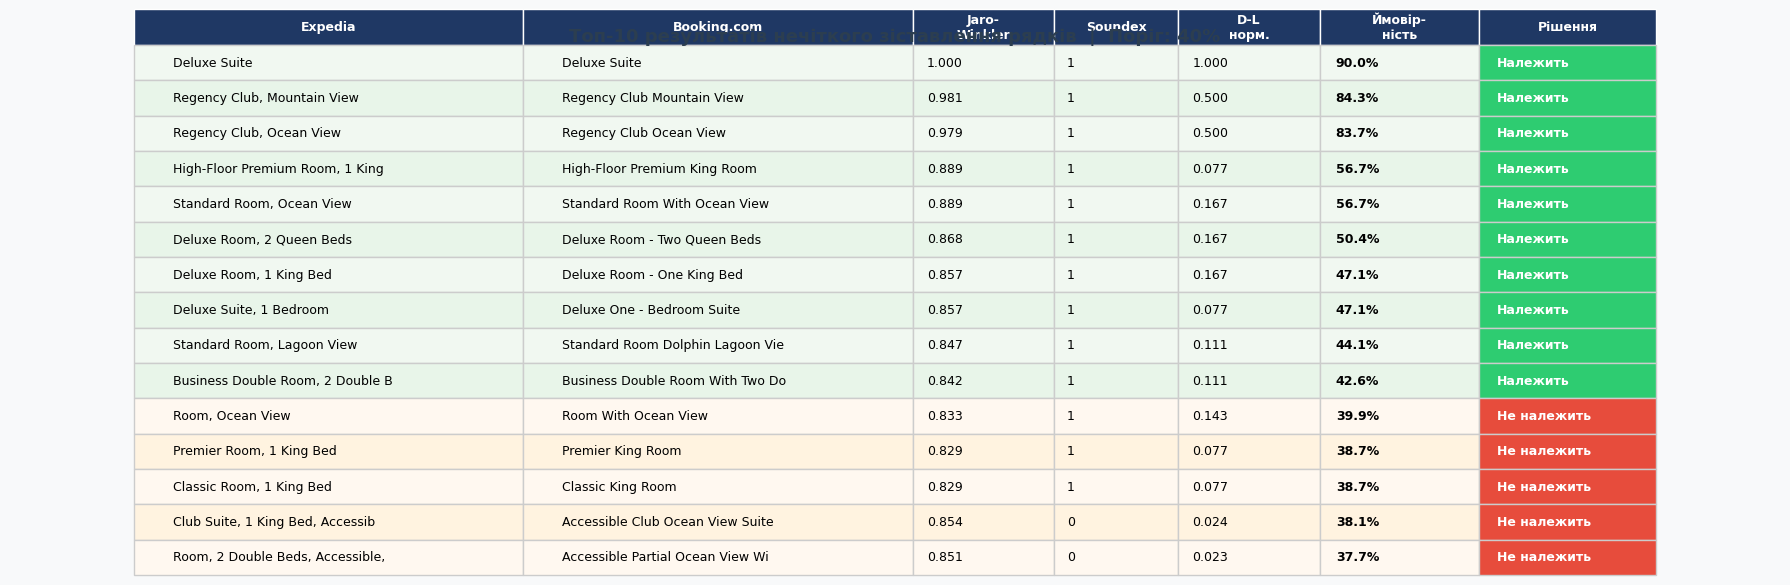

In [141]:
fig, ax = plt.subplots(figsize=(18, 6))
ax.axis('off')
fig.patch.set_facecolor('#F8F9FA')

cell_data = []
for _, row in top15.iterrows():
    cell_data.append([
        row["Expedia"][:32],
        row["Booking.com"][:32],
        f"{row['jw']:.3f}",
        f"{int(row['soundex'])}",
        f"{row['dl']:.3f}",
        f"{row['probability']}%",
        row["decision"]
    ])

col_labels = ["Expedia", "Booking.com", "Jaro-\nWinkler", "Soundex", "D-L\nнорм.", "Ймовір-\nність", "Рішення"]
col_widths = [0.22, 0.22, 0.08, 0.07, 0.08, 0.09, 0.10]

table = ax.table(
    cellText=cell_data,
    colLabels=col_labels,
    cellLoc='left',
    loc='center',
    colWidths=col_widths
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.2)

for j in range(len(col_labels)):
    cell = table[0, j]
    cell.set_facecolor('#1F3864')
    cell.set_text_props(color='white', fontweight='bold', fontsize=9)
    cell.set_edgecolor('white')

for i in range(1, len(cell_data) + 1):
    row_data = cell_data[i - 1]
    is_belongs = row_data[6] == "Належить"

    for j in range(len(col_labels)):
        cell = table[i, j]
        cell.set_edgecolor('#CCCCCC')

        if is_belongs:
            bg = '#E8F5E9' if i % 2 == 0 else '#F1F8F1'
        else:
            bg = '#FFF3E0' if i % 2 == 0 else '#FFF8F0'

        cell.set_facecolor(bg)

        if j == 6:
            if is_belongs:
                cell.set_facecolor('#2ECC71')
                cell.set_text_props(color='white', fontweight='bold')
            else:
                cell.set_facecolor('#E74C3C')
                cell.set_text_props(color='white', fontweight='bold')

        if j == 5:
            cell.set_text_props(fontweight='bold')

ax.set_title(
    f'Топ-10 результатів нечіткого зіставлення рядків  |  Поріг: {THRESHOLD*100:.0f}%',
    fontsize=13, fontweight='bold', pad=20, color='#2C3E50'
)

plt.tight_layout()
plt.show()

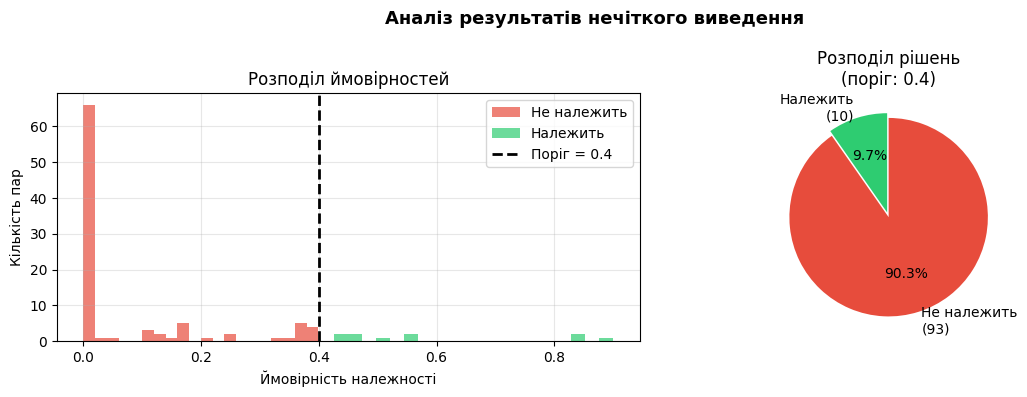

In [142]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Аналіз результатів нечіткого виведення', fontsize=13, fontweight='bold')

ax = axes[0]
belongs_data     = data[data["result"] >= THRESHOLD]["result"]
not_belongs_data = data[data["result"] <  THRESHOLD]["result"]

ax.hist(not_belongs_data, bins=20, color='#E74C3C', alpha=0.7, label='Не належить')
ax.hist(belongs_data,     bins=20, color='#2ECC71', alpha=0.7, label='Належить')
ax.axvline(x=THRESHOLD, color='black', linestyle='--', linewidth=2,
           label=f'Поріг = {THRESHOLD}')
ax.set_xlabel('Ймовірність належності')
ax.set_ylabel('Кількість пар')
ax.set_title('Розподіл ймовірностей')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
belongs_count     = len(data[data["result"] >= THRESHOLD])
not_belongs_count = len(data[data["result"] <  THRESHOLD])

ax.pie(
    [belongs_count, not_belongs_count],
    labels=[f'Належить\n({belongs_count})', f'Не належить\n({not_belongs_count})'],
    colors=['#2ECC71', '#E74C3C'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0)
)
ax.set_title(f'Розподіл рішень\n(поріг: {THRESHOLD})')

plt.tight_layout()
plt.show()

In [143]:
# Порівняння двох підходів:
# 1) простий поріг по Jaro-Winkler
# 2) нечітка модель з урахуванням кількох метрик

JW_THRESHOLD = 0.8

comparison_df = data.copy()
comparison_df["jw_decision"]    = comparison_df["jw"].apply(lambda x: "Належить" if x >= JW_THRESHOLD else "Не належить")
comparison_df["fuzzy_decision"] = comparison_df["decision"]

summary = (
    comparison_df
    .groupby(["jw_decision", "fuzzy_decision"])  
    .size()
    .reset_index(name="count")
)

print("Порівняння рішень (простий поріг по JW vs нечітка модель):\n")
print(tabulate(summary, headers="keys", tablefmt="github", showindex=False))

# Приклади, де простий поріг відкидає, а нечітка модель вважає, що терміни належать
examples = comparison_df[(comparison_df["jw_decision"] == "Не належить") &
                         (comparison_df["fuzzy_decision"] == "Належить")]

if not examples.empty:
    print("\nПриклади, де Jaro-Winkler < порогу, але нечітка модель каже 'Належить':\n")
    print(
        examples[["Expedia", "Booking.com", "jw", "result", "probability", "decision"]]
        .sort_values("result", ascending=False)
        .head(10)
        .to_string(index=False)
    )
else:
    print("\nНемає прикладів, де моделі суттєво розходяться при обраному порозі JW.")

Порівняння рішень (простий поріг по JW vs нечітка модель):

| jw_decision   | fuzzy_decision   |   count |
|---------------|------------------|---------|
| Належить      | Належить         |      10 |
| Належить      | Не належить      |      14 |
| Не належить   | Не належить      |      79 |

Немає прикладів, де моделі суттєво розходяться при обраному порозі JW.
